In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
df = pd.read_csv("New Clean Data.csv")
df.head(2)

,Unnamed: 0,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Time,Customer_Age,Customer_Loyalty_Tier,Location,Store_ID,Product_SKU,Product_Category,Purchase_Amount,Payment_Method,Device_Type,IP_Address,Fraud_Flag,Footfall_Count,High_Risk_Transaction
0,0,702bdd9b-9c93-41e3-9dbb-a849b2422080,119dca0b-8554-4b2d-9bec-e964eaf6af97,2025-07-27,04:04:15,56,Silver,San Francisco,FLAGSHIP-LA,NEBULA-SERUM-07,Concealer,158.24,Mobile Payment,Desktop,239.249.58.237,0,333,0
1,1,2e64c346-36bc-4acf-bc2b-8b0fdf46abc5,299df086-26c4-4708-b6d7-fcaeceb14637,2025-03-14,20:23:23,46,Platinum,Zurich,BOUTIQUE-SHANGHAI,STELLAR-FOUND-03,Lipstick,86.03,Credit Card,Tablet,84.49.227.90,0,406,0


C:\Users\waghv\AppData\Local\Temp\ipykernel_119188\3430749960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df["Fraud_Flag"], data=df, palette=['green','red'])


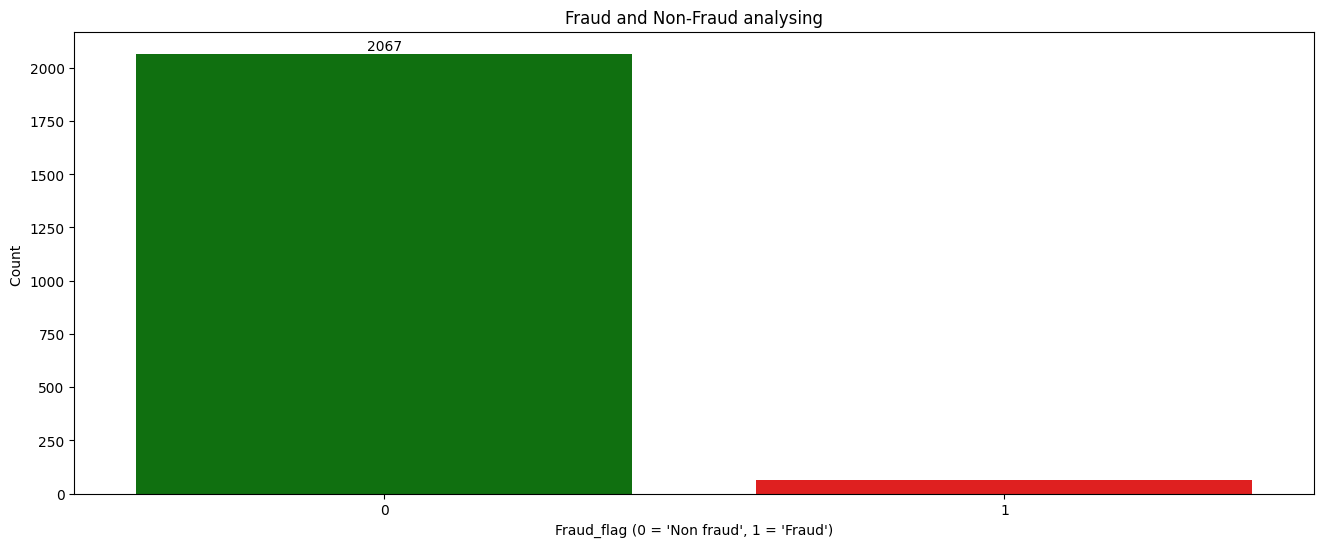

In [65]:
# Calcualte the fraud and Non-Fraud 

plt.figure(figsize=(16,6))
ax = sns.countplot(x=df["Fraud_Flag"], data=df, palette=['green','red'])
plt.title("Fraud and Non-Fraud analysing")
plt.xlabel("Fraud_flag (0 = 'Non fraud', 1 = 'Fraud')")
plt.ylabel("Count ")
ax.bar_label(ax.containers[0])
plt.show()


In [17]:
''' Above Fraud Graph Insights 
        
        - in it we can see that the data set is highly imbalence 
        - there are more Non-Fraud and small Fraud but it is highly affect 
 
 '''

' Above Fraud Graph Insights \n\n        - in it we can see that the data set is highly imbalence \n        - there are more Non-Fraud and small Fraud but it is highly affect \n\n '

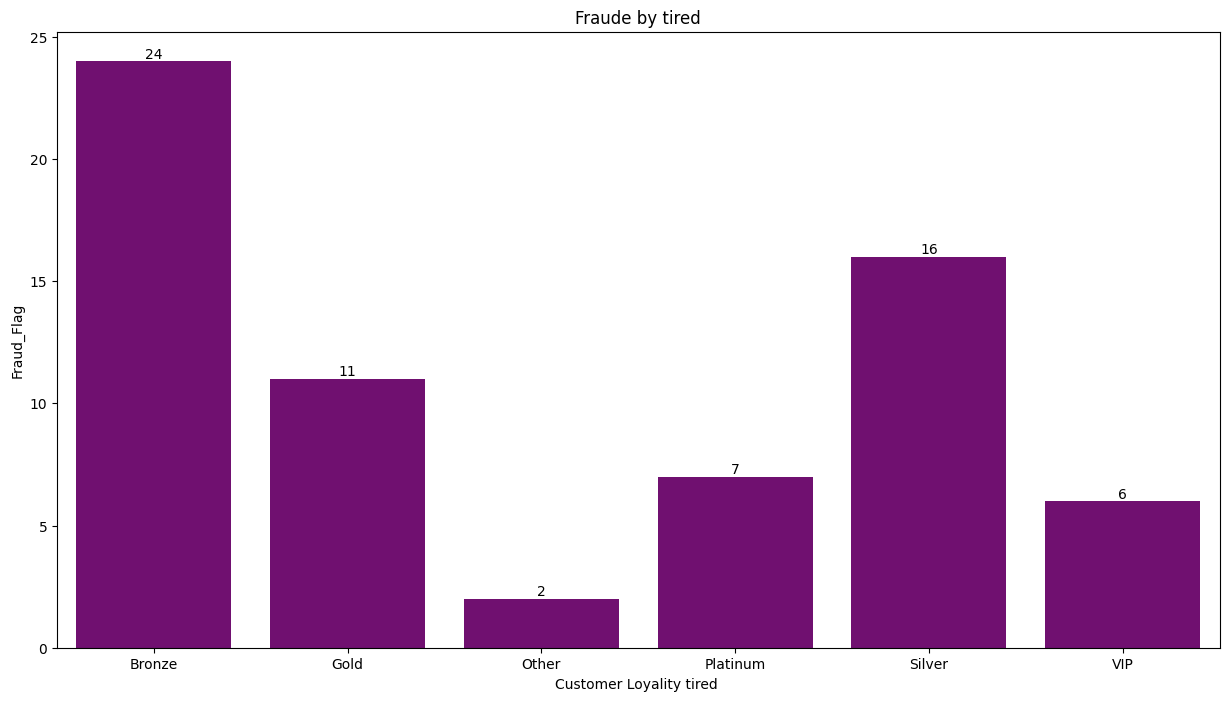

In [104]:
# No of Fraud divide with tired
plt.figure(figsize=(15,8))
Fraud_by_tired = df.groupby(df["Customer_Loyalty_Tier"])["Fraud_Flag"].sum()
ax = sns.barplot(data=Fraud_by_tired, color="purple")
plt.title("Fraude by tired")
plt.xlabel("Customer Loyality tired ")
plt.ylabel("Fraud_Flag")
ax.bar_label(ax.containers[0])
plt.show()


In [ ]:
''' 
 we can see that in  Above Graph there are more fraud happen in Bronze it is 24
 2nd position it is silver in that happen 16 frauds 

 Bronze > Silver > Gold > Platinum > VIP > Others

 - Higher loyalty tiers (Platinum, VIP etc.) have fewer fraud cases
 - Fraudsters are more likely to target customers with weaker loyalty status. 

'''

<Axes: xlabel='Customer_Age', ylabel='Purchase_Amount'>

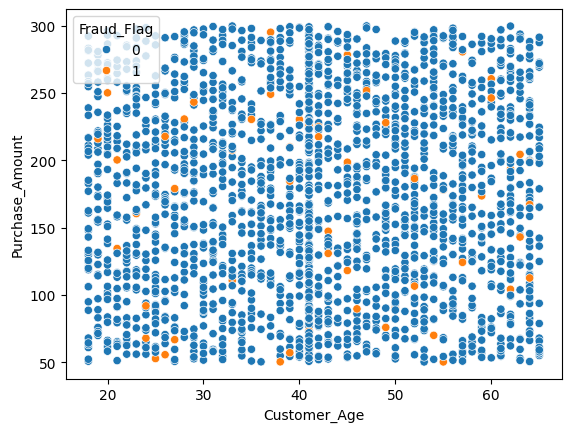

In [81]:
sns.scatterplot(x=df["Customer_Age"],y=df["Purchase_Amount"], hue='Fraud_Flag',data=df)

In [ ]:
'''
    Insight:
        - Fraudulent transactions are more common in younger to middle-aged customers.  
        - Older age groups show fewer fraud cases compared to younger ones.  
''' 

Text(0.5, 1.0, 'Fraud by Payment Methods')

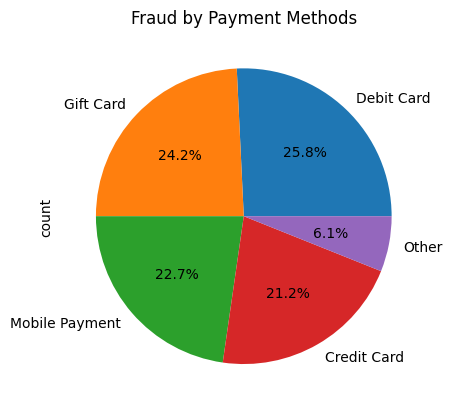

In [110]:
# Fraud Payment Method 

fraud_Payment_Method = df[df["Fraud_Flag"]==1]["Payment_Method"].value_counts()
fraud_Payment_Method.plot.pie(autopct = '%1.1f%%')
plt.title("Fraud by Payment Methods")

In [ ]:

''' 
    we can see that the payment method 'Debit card' has more occur Fraud by this method 

    fraud using payment methods Debit card > gift card > MobilePayment > Credit card
    
    - which highlights the need for stronger authentication.  

'''

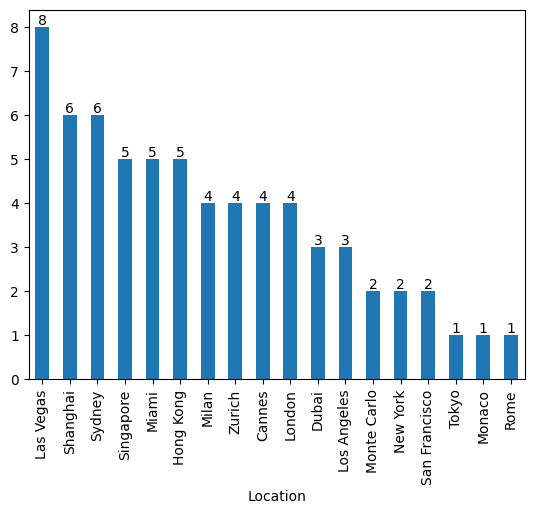

In [131]:
# Fraud by Location
 
Fraud_by_Loaction = df[df["Fraud_Flag"]==1]["Location"].value_counts()
ax = Fraud_by_Loaction.plot.bar()
ax.bar_label(ax.containers[0])
plt.show()

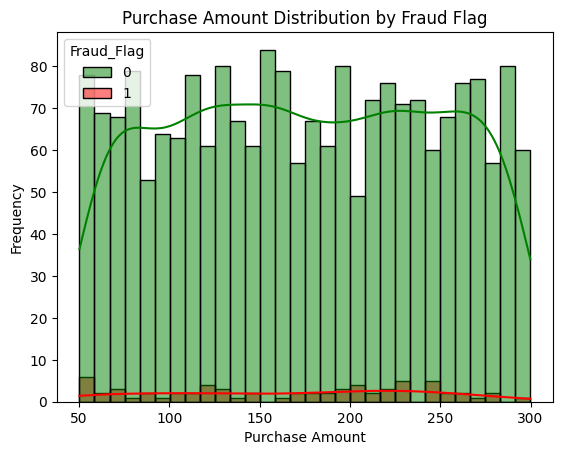

In [136]:
sns.histplot(data=df, x='Purchase_Amount', hue='Fraud_Flag', kde=True, palette=['green','red'], bins=30)
plt.title("Purchase Amount Distribution by Fraud Flag")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

In [ ]:
''' 
Insight:
# - Legitimate transactions (green) are spread across all purchase ranges.  
# - Fraudulent transactions (red) cluster more around **mid-to-high purchase amounts**.  
# - Very few fraud cases exist at very low purchase amounts.  

# Interpretation:
# Fraudsters may prefer targeting **medium to large purchases** 
# to maximize impact, while small-value fraud attempts are rare.  
# This insight can help businesses **flag high-value transactions for extra verification**.  
# ----------------------
'''